In [33]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pankeshpatel/insurance")

print("Path to dataset files:", path)

Path to dataset files: /Users/kpvarma/.cache/kagglehub/datasets/pankeshpatel/insurance/versions/1


In [34]:
import pandas as pd
df=pd.read_csv('insurance_data.csv')
df

,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1
5,56,1
6,55,0
7,60,1
8,62,1
9,61,1


In [35]:
df.shape


(27, 2)

In [36]:
df.columns


Index(['age', 'bought_insurance'], dtype='object')

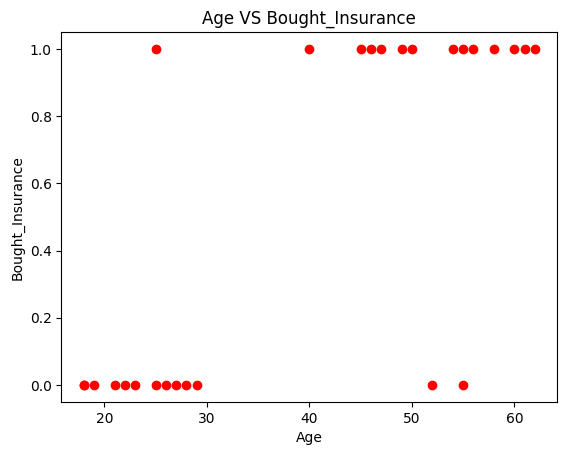

In [37]:
import matplotlib.pyplot as plt
plt.scatter(df.age,df.bought_insurance,marker='o',color='red')
plt.xlabel('Age')
plt.ylabel('Bought_Insurance')
plt.title('Age VS Bought_Insurance')
plt.show()


In [38]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df.age,df.bought_insurance,train_size=0.8)

In [39]:
x_train.shape

(21,)

In [40]:
x_test.shape


(6,)

In [41]:
x_train = x_train.values.reshape(-1, 1)
x_test = x_test.values.reshape(-1, 1)
#scikit-learn expects a 2D array
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(max_iter=1000)
lr.fit(x_train,y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [42]:
y_pred=lr.predict(x_test)


In [43]:
y_test


0     0
1     0
5     1
21    0
16    1
14    1
Name: bought_insurance, dtype: int64

In [44]:
from sklearn.metrics import accuracy_score, log_loss
y_pred_proba = lr.predict_proba(x_test)
loss = log_loss(y_test, y_pred_proba)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"Log Loss: {loss:.4f}")

Accuracy: 0.8333
Log Loss: 0.5339
